In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
dt = 1e-3
steps = 7500
n = 3
G = 1

In [12]:
def kinetic_energy(masses, velocities):
    return 0.5 * np.sum(masses * np.linalg.norm(velocities, axis=1) ** 2)

def potencial_energy(masses, positions):
    U = 0
    for i in range(n):
        for j in range(i + 1, n):
            r_ij = np.linalg.norm(positions[j] - positions[i])
            U += G * masses[i] * masses[j] / r_ij
    return U

In [37]:
def derivs(masses, states):
    x, v = states[:n], states[n:]
    a = np.zeros_like(x)
    for i in range(n):
        for j in range(i + 1, n):
            r_ij = x[j] - x[i]
            d = r_ij / np.linalg.norm(r_ij) ** 3
            a[i] += G * masses[j] * d
            a[j] -= G * masses[i] * d
    return np.concatenate([v, a])

def tot_e(masses, state):
    x, v = state[:n], state[n:]
    return kinetic_energy(masses, v), potencial_energy(masses, x)

def rk4(masses, state):
    trajectory = [state.copy()]
    energy = [tot_e(masses, state)]
    for _ in range(steps - 1):
        k1 = derivs(masses, state)
        k2 = derivs(masses, state + 0.5 * dt * k1)
        k3 = derivs(masses, state + 0.5 * dt * k2)
        k4 = derivs(masses, state + dt * k3)
        state += dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6
        trajectory.append(state.copy())
        energy.append(tot_e(masses, state))

    return np.array(trajectory), np.array(energy)


def verlet(masses, state):
    trajectory = [state.copy()]
    energy = [tot_e(masses, state)]

    # Euler step
    state += derivs(masses, state) * dt
    trajectory.append(state.copy())
    energy.append(tot_e(masses, state))

    for _ in range(steps - 2):
        a = derivs(masses, state)[n:]
        x = 2 * trajectory[-1][:n] + a*dt*dt - trajectory[-2][:n]
        v = (x - trajectory[-1][:n]) / dt
        state = np.concatenate([x, v])
        trajectory.append(state)
        energy.append(tot_e(masses, state))
    
    return np.array(trajectory[:-1]), np.array(energy)

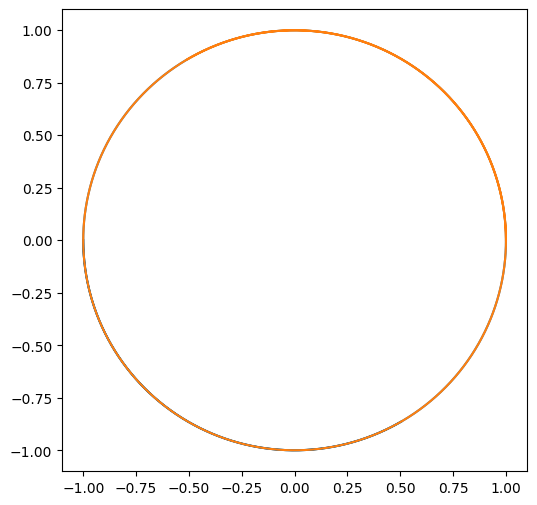

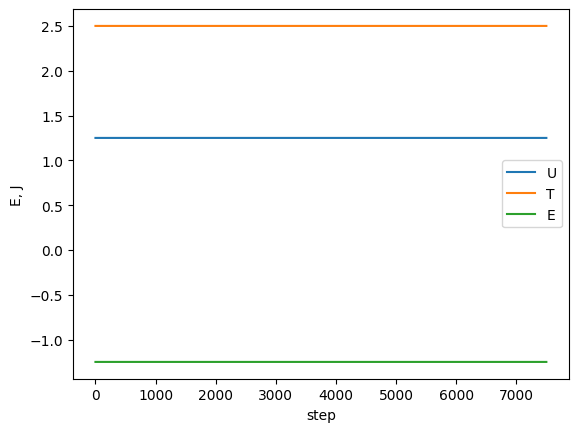

In [27]:
def run_3_body(x, v, m):
    traj, enrg = rk4(m, np.concatenate([x, v]))
    plt.figure(figsize=(6, 6))
    for i in range(n):
        plt.plot(traj[:, i, 0], traj[:, i, 1])
    plt.show()

    plt.plot(np.arange(steps), enrg[:, 0], label='U')
    plt.plot(np.arange(steps), enrg[:, 1], label='T')
    plt.plot(np.arange(steps), enrg[:, 0] - enrg[:, 1], label='E')
    plt.xlabel(r'step')
    plt.ylabel(r'E, J')
    plt.legend()
    plt.show()

run_3_body(
    x=np.array([[-1.0, 0], [1.0, 0], [0, 0]]),
    v=np.array([[0, -np.sqrt(5)/2], [0, np.sqrt(5)/2], [0, 0]]),
    m=np.array([1.0, 1, 1]),
)

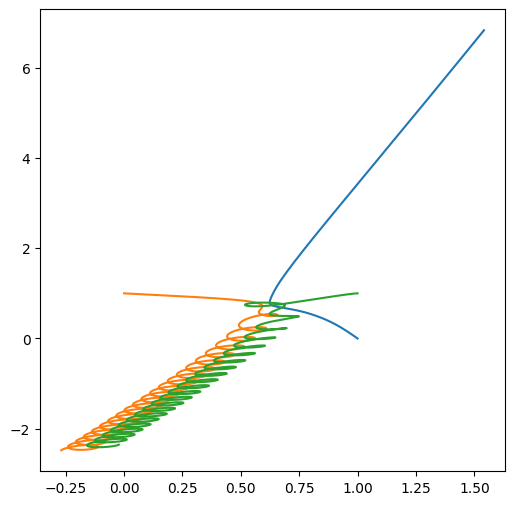

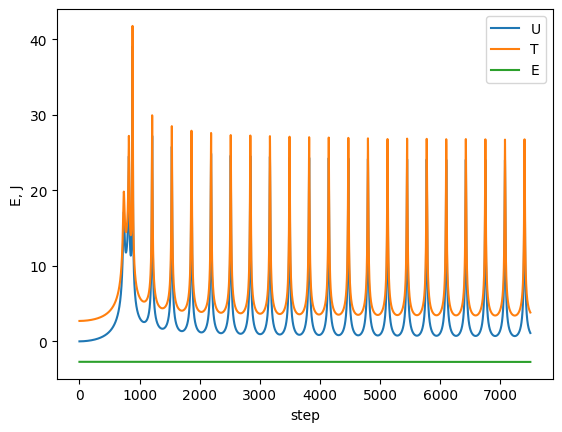

In [28]:
run_3_body(
    x=np.array([[1.0, 0], [0, 1], [1, 1]]),
    v=np.array([[0.0, 0], [0, 0], [-0.1, 0]]),
    m=np.array([1.0, 1, 1]),
)

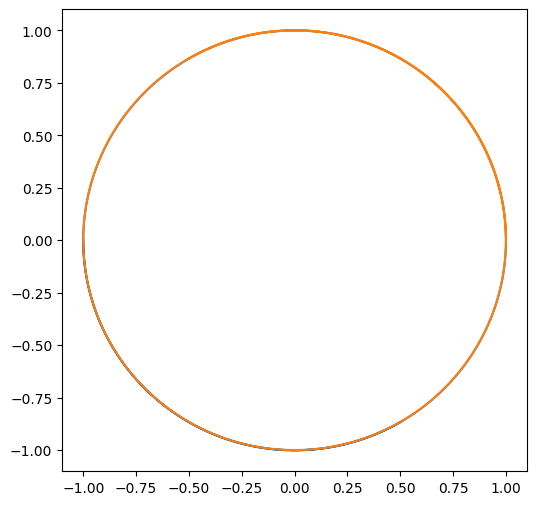

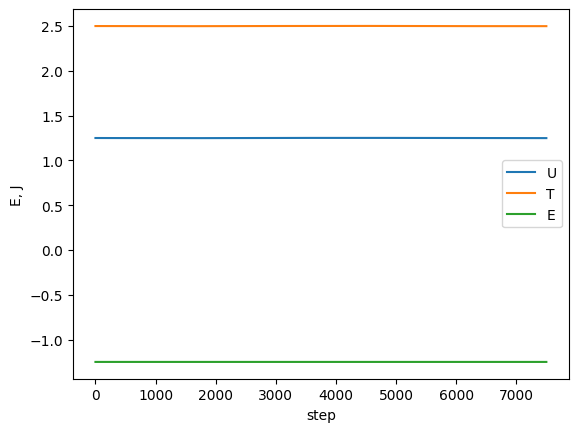

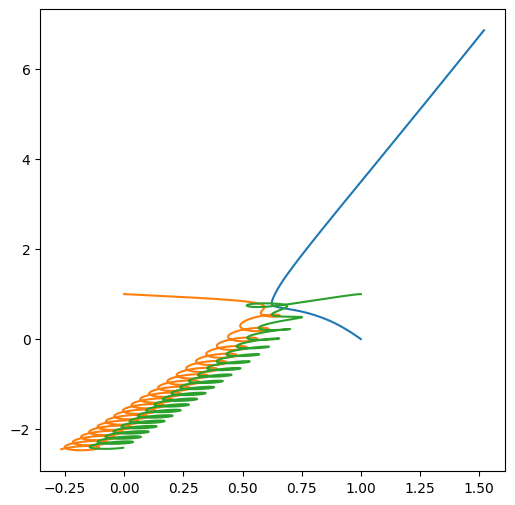

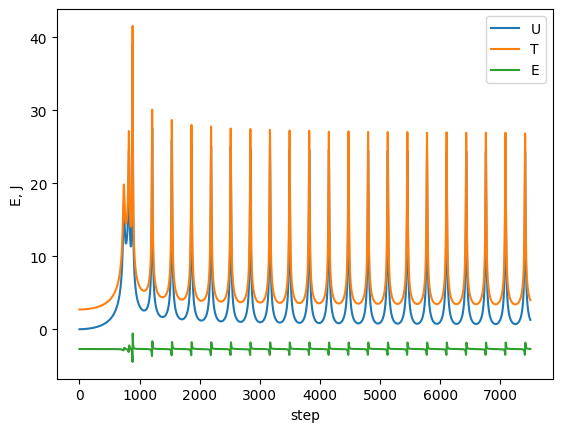

In [39]:
def run_verlet(x, v, m):
    traj, enrg = verlet(m, np.concatenate([x, v]))
    plt.figure(figsize=(6, 6))
    for i in range(n):
        plt.plot(traj[:, i, 0], traj[:, i, 1])
    plt.show()

    plt.plot(np.arange(steps), enrg[:, 0], label='U')
    plt.plot(np.arange(steps), enrg[:, 1], label='T')
    plt.plot(np.arange(steps), enrg[:, 0] - enrg[:, 1], label='E')
    plt.xlabel(r'step')
    plt.ylabel(r'E, J')
    plt.legend()
    plt.show()

run_verlet(
    x=np.array([[-1.0, 0], [1.0, 0], [0, 0]]),
    v=np.array([[0, -np.sqrt(5)/2], [0, np.sqrt(5)/2], [0, 0]]),
    m=np.array([1.0, 1, 1]),
)

run_verlet(
    x=np.array([[1.0, 0], [0, 1], [1, 1]]),
    v=np.array([[0.0, 0], [0, 0], [-0.1, 0]]),
    m=np.array([1.0, 1, 1]),
)